# Importing list

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Load

In [2]:
df=pd.read_csv(r"C:\Users\arya wardhana\Documents\Rakamin\Mini Project\Improving Employee Retention by Predicting Employee Attrition Using Machine Learning\tahap01\retention.csv", sep=";")

In [3]:
df.sample(5)

,Username,EnterpriseID,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,...,NomorHP,Email,TingkatPendidikan,PernahBekerja,IkutProgramLOP,AlasanResign,TanggalLahir,TanggalHiring,TanggalPenilaianKaryawan,TanggalResign
10,puzzledCake4,105548,Belum_menikah,Pria,FullTime,Software Engineer (Front End),Mid_level,Kurang,Jakarta Timur,CareerBuilder,...,+6281263218xxx,puzzledCake4844@icloud.com,Sarjana,1,1.0,ganti_karir,1975-12-17,2010-7-20,2020-1-14,2019-01-12
189,grudgingMeerkat3,106008,Belum_menikah,Wanita,Outsource,Software Engineer (Back End),Freshgraduate_program,Bagus,Jakarta Timur,CareerBuilder,...,+6285714869xxx,grudgingMeerkat3383@proton.com,Sarjana,1,NaN,NaN,1986-04-17,2011-01-10,2017-02-03,-
98,forsakenWidgeon8,100639,Lainnya,Wanita,FullTime,Software Engineer (Front End),Mid_level,Sangat_kurang,Jakarta Barat,Website,...,+6283347244xxx,forsakenWidgeon8050@proton.com,Sarjana,1,NaN,masih_bekerja,1987-05-14,2012-2-20,2020-1-29,-
214,peacefulEggs3,106621,Belum_menikah,Pria,FullTime,Software Engineer (Android),Freshgraduate_program,Biasa,Jakarta Utara,LinkedIn,...,+6285683205xxx,peacefulEggs3191@yahoo.com,Magister,1,NaN,leadership,1985-03-14,2014-2-17,2020-01-11,2014-8-19
161,needfulZebra5,111703,Menikah,Pria,FullTime,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Pusat,Diversity_Job_Fair,...,+6285507346xxx,needfulZebra5962@gmail.com,Sarjana,1,NaN,tidak_bisa_remote,1983-06-14,2013-2-18,2018-02-12,2015-4-15


# EDA

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Username                            287 non-null    str    
 1   EnterpriseID                        287 non-null    int64  
 2   StatusPernikahan                    287 non-null    str    
 3   JenisKelamin                        287 non-null    str    
 4   StatusKepegawaian                   287 non-null    str    
 5   Pekerjaan                           287 non-null    str    
 6   JenjangKarir                        287 non-null    str    
 7   PerformancePegawai                  287 non-null    str    
 8   AsalDaerah                          287 non-null    str    
 9   HiringPlatform                      287 non-null    str    
 10  SkorSurveyEngagement                287 non-null    int64  
 11  SkorKepuasanPegawai                 282 non-null    floa

## Missing

In [5]:
print("=== MISSING / NULL VALUES ===")
null_summary = pd.DataFrame({
    'Null Count': df.isnull().sum(),
    'Null Percentage (%)': (df.isnull().sum() / len(df)) * 100
})
display(null_summary[null_summary['Null Count'] > 0] if df.isnull().sum().sum() > 0 else "No missing values found!")

=== MISSING / NULL VALUES ===


,Null Count,Null Percentage (%)
SkorKepuasanPegawai,5,1.742160
JumlahKeikutsertaanProjek,3,1.045296
JumlahKeterlambatanSebulanTerakhir,1,0.348432
JumlahKetidakhadiran,6,2.090592
IkutProgramLOP,258,89.895470
AlasanResign,66,22.996516


In [6]:
cols=["SkorKepuasanPegawai",
      "JumlahKeikutsertaanProjek",
      "JumlahKeterlambatanSebulanTerakhir",
      "JumlahKetidakhadiran",
      "IkutProgramLOP"]

df[cols].describe().round(2)

,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,IkutProgramLOP
count,282.00,284.00,286.00,281.00,29.00
mean,3.90,1.18,0.41,10.45,0.52
std,0.91,2.29,1.28,6.90,0.51
min,1.00,0.00,0.00,1.00,0.00
25%,3.00,0.00,0.00,5.00,0.00
50%,4.00,0.00,0.00,10.00,1.00
75%,5.00,0.00,0.00,15.00,1.00
max,5.00,8.00,6.00,55.00,1.00


### Handling

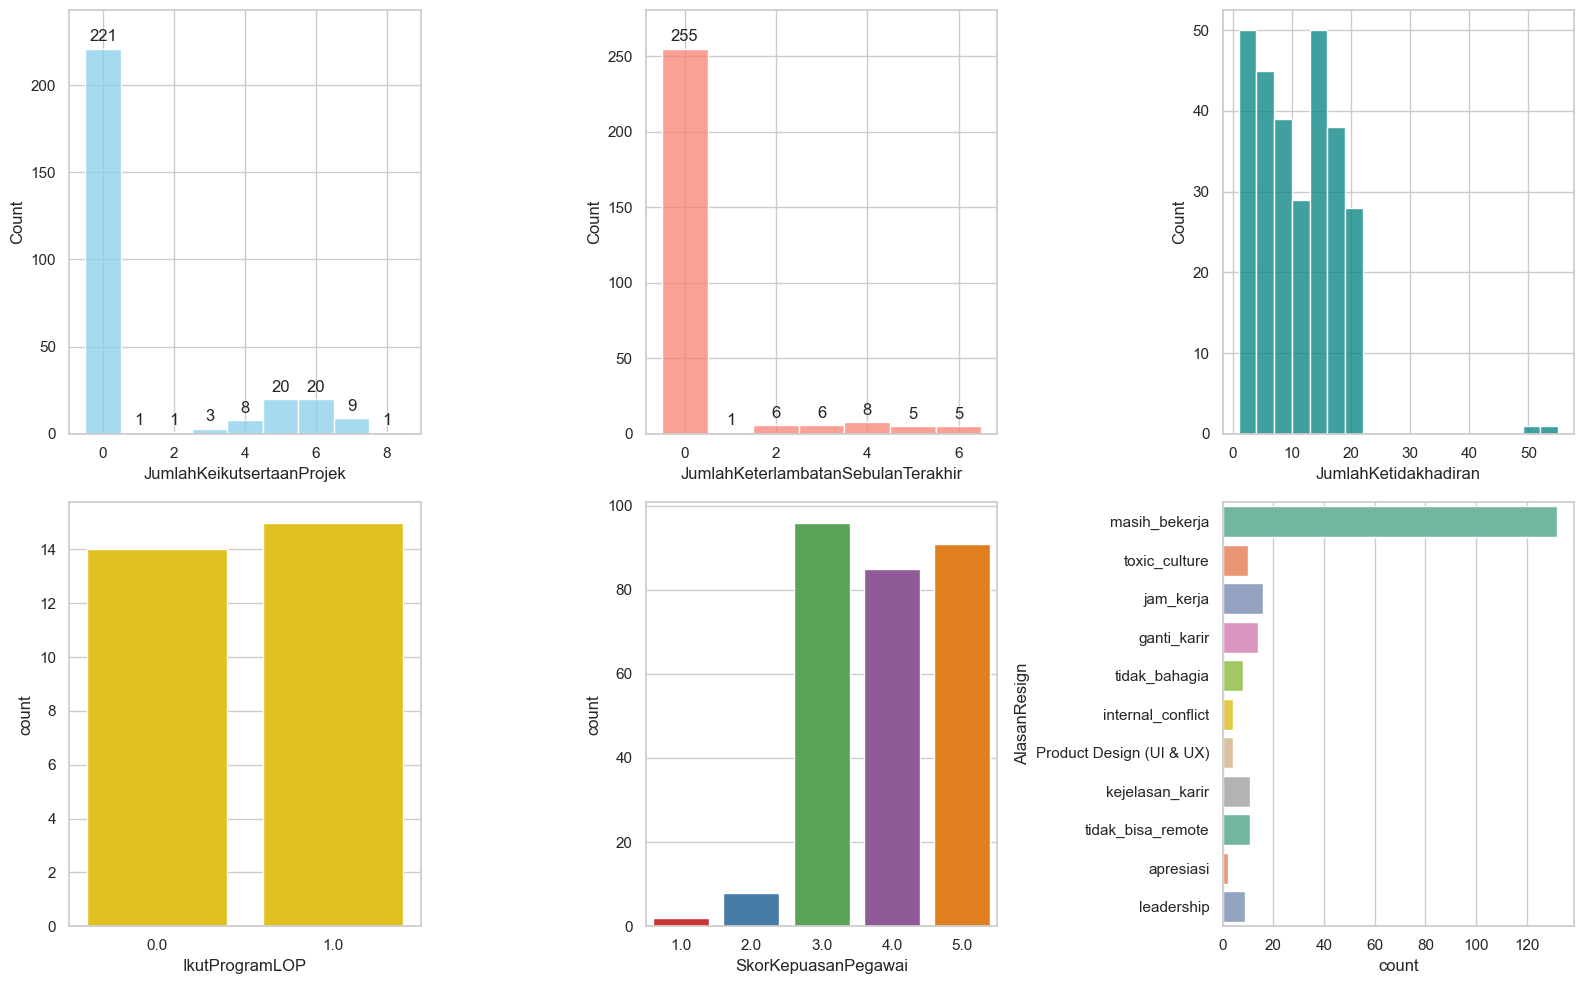

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

#Numerical Plots (Histograms with KDE)
sns.histplot(df["JumlahKeikutsertaanProjek"], ax=axes[0, 0], color='skyblue', discrete=True)
#Add total counts on top of each bar
axes[0, 0].bar_label(axes[0, 0].containers[0], padding=3)
#Add extra padding at the top so labels don't get cut off
axes[0, 0].margins(y=0.1)

sns.histplot(df["JumlahKeterlambatanSebulanTerakhir"], ax=axes[0, 1], color='salmon', discrete=True)
axes[0, 1].bar_label(axes[0, 1].containers[0], padding=3)
axes[0, 1].margins(y=0.1)

sns.histplot(df["JumlahKetidakhadiran"], ax=axes[0, 2], color='teal')

# Categorical Distributions
sns.countplot(x="IkutProgramLOP", data=df, ax=axes[1, 0], color='gold', legend=False)

sns.countplot(
    x="SkorKepuasanPegawai",
    data=df,
    ax=axes[1, 1],
    hue="SkorKepuasanPegawai",
    palette="Set1",
    legend=False,  # Hides unnecessary legend created by hue
)

sns.countplot(
    y="AlasanResign",
    data=df,
    ax=axes[1, 2],
    hue="AlasanResign",
    palette="Set2",
    legend=False,
)

plt.tight_layout()
plt.show()

In [8]:
df["SkorKepuasanPegawai"]=df["SkorKepuasanPegawai"].fillna(df["SkorKepuasanPegawai"].median())
df["JumlahKeikutsertaanProjek"]=df["JumlahKeikutsertaanProjek"].fillna(df["JumlahKeikutsertaanProjek"].mode())
df["JumlahKeterlambatanSebulanTerakhir"]=df["JumlahKeterlambatanSebulanTerakhir"].fillna(df["JumlahKeterlambatanSebulanTerakhir"].median())
df["JumlahKetidakhadiran"]=df["JumlahKetidakhadiran"].fillna(df["JumlahKetidakhadiran"].median())
df["IkutProgramLOP"]=df["IkutProgramLOP"].fillna(0)
df["AlasanResign"]=df["AlasanResign"].fillna("Lainnya")

## Dupli

In [9]:
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_count}")

Total duplicate rows: 0


## Adding Columns

In [10]:
#TanggalLahir change into date format
df["TanggalLahir"] = pd.to_datetime(df["TanggalLahir"])

#Extract birth year assume the year is 2020/10
df["Age"] = 2020 - df["TanggalLahir"].dt.year

In [11]:
#Convert columns to datetime
#errors='coerce' to turns "-" or any invalid date into NaN
df["TanggalHiring"] = pd.to_datetime(df["TanggalHiring"], errors="coerce")
df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")

#Assume cutoff date (2020/10/01)
cutoff_date = pd.Timestamp("2020-10-01")

#Fill NaN values with the cutoff date
end_date = df["TanggalResign"].fillna(cutoff_date)

#counting how long the workdays
df["LamaBekerja(Hari)"] = (end_date - df["TanggalHiring"]).dt.days

#Fix any potential negative days (e.g. if hired after Sept 2020)
df["LamaBekerja(Hari)"] = df["LamaBekerja(Hari)"].clip(lower=0)

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\2291396135.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TanggalResign"] = pd.to_datetime(df["TanggalResign"], errors="coerce")


In [12]:
#List of values or patterns that represent active employees
still_working=["masih_bekerja", "-", ""]

# Check if 'AlasanResign' is NOT in still_working_values AND is NOT missing (NaN)
is_resigned = (
    ~df["AlasanResign"].isin(still_working) & df["AlasanResign"].notna()
)

# Convert True/False boolean directly into 1/0 integers
df["Resign"] = is_resigned.astype(int)

In [13]:
# Check total count of Resigned (1) vs Still Working (0)
print(df["Resign"].value_counts())

# Cross-tabulate with original AlasanResign to double check
print(pd.crosstab(df["AlasanResign"].fillna("NaN"), df["Resign"]))

Resign
1    155
0    132
Name: count, dtype: int64
Resign                      0   1
AlasanResign                     
Lainnya                     0  66
Product Design (UI & UX)    0   4
apresiasi                   0   2
ganti_karir                 0  14
internal_conflict           0   4
jam_kerja                   0  16
kejelasan_karir             0  11
leadership                  0   9
masih_bekerja             132   0
tidak_bahagia               0   8
tidak_bisa_remote           0  11
toxic_culture               0  10


## Dropping Columns

In [14]:
col_to_drop=["Username",
             "EnterpriseID",
             "NomorHP",
             "Email",
             "TanggalLahir",
             "TanggalHiring",
             "TanggalPenilaianKaryawan",
             "TanggalResign",
             "AlasanResign"]

df01=df.drop(columns=col_to_drop)
df01.sample(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,PernahBekerja,IkutProgramLOP,Age,LamaBekerja(Hari),Resign
78,Bercerai,Pria,FullTime,Data Analyst,Mid_level,Sangat_bagus,Jakarta Barat,Employee_Referral,4,4.0,0.0,0.0,19.0,Sarjana,1,0.0,37,2558,0
122,Belum_menikah,Wanita,Outsource,Software Engineer (Android),Mid_level,Kurang,Jakarta Timur,LinkedIn,3,4.0,NaN,0.0,14.0,Sarjana,1,0.0,41,3104,0
21,Lainnya,Wanita,FullTime,Scrum Master,Mid_level,Sangat_kurang,Jakarta Barat,Indeed,3,4.0,NaN,0.0,10.0,Sarjana,1,0.0,39,3376,0
244,Belum_menikah,Wanita,FullTime,Software Engineer (Back End),Senior_level,Bagus,Jakarta Pusat,Google_Search,4,4.0,0.0,0.0,4.0,Sarjana,1,0.0,47,2205,1
276,Belum_menikah,Pria,FullTime,Software Engineer (Back End),Freshgraduate_program,Bagus,Jakarta Timur,CareerBuilder,3,3.0,0.0,0.0,13.0,Magister,1,0.0,34,2771,1


## Rechecking

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\3897543744.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\3897543744.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\3897543744.py:28: FutureWarning:

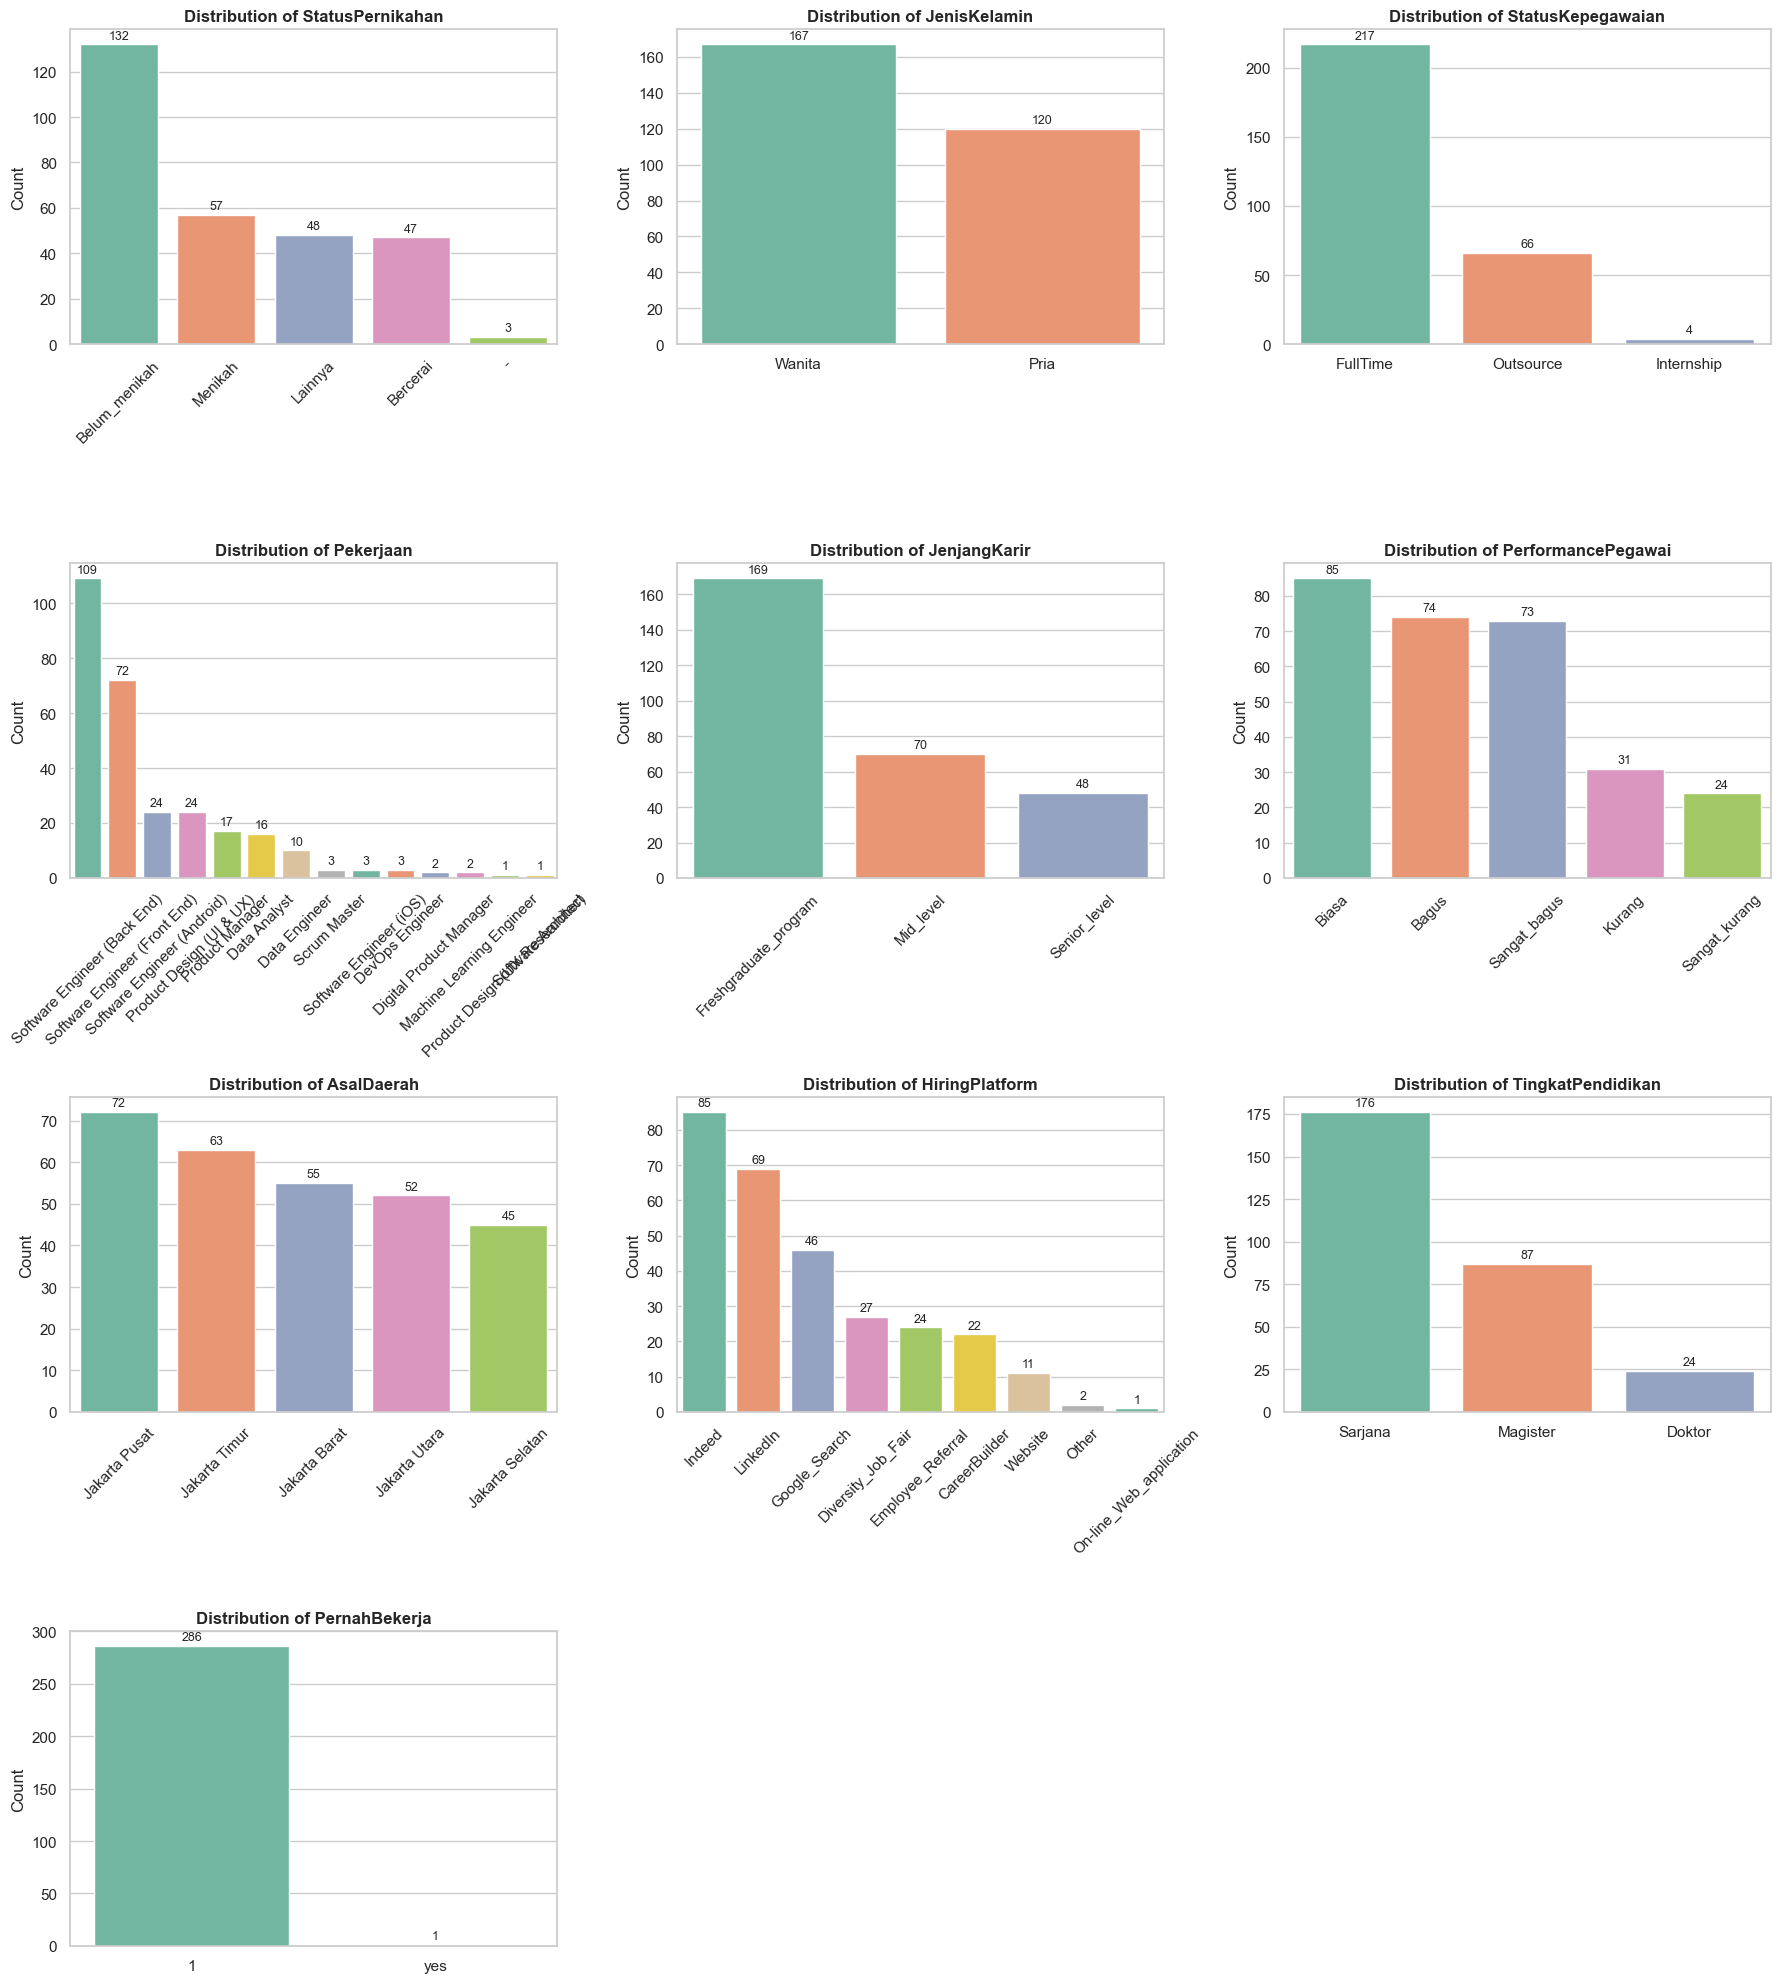

In [15]:
import math

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Handling

In [16]:
#replace
df01["StatusPernikahan"]=df01["StatusPernikahan"].replace("-", "Lainnya")

#drop
df01=df01.drop(columns="PernahBekerja")

In [17]:
df01.head(5)

,StatusPernikahan,JenisKelamin,StatusKepegawaian,Pekerjaan,JenjangKarir,PerformancePegawai,AsalDaerah,HiringPlatform,SkorSurveyEngagement,SkorKepuasanPegawai,JumlahKeikutsertaanProjek,JumlahKeterlambatanSebulanTerakhir,JumlahKetidakhadiran,TingkatPendidikan,IkutProgramLOP,Age,LamaBekerja(Hari),Resign
0,Belum_menikah,Pria,Outsource,Software Engineer (Back End),Freshgraduate_program,Sangat_bagus,Jakarta Timur,Employee_Referral,4,4.0,0.0,0.0,9.0,Magister,1.0,48,3552,0
1,Belum_menikah,Pria,FullTime,Data Analyst,Freshgraduate_program,Sangat_kurang,Jakarta Utara,Website,4,4.0,4.0,0.0,3.0,Sarjana,1.0,36,1622,1
2,Menikah,Pria,FullTime,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Timur,Indeed,4,3.0,0.0,0.0,11.0,Magister,1.0,46,1353,1
3,Belum_menikah,Pria,Outsource,Software Engineer (Front End),Freshgraduate_program,Bagus,Jakarta Pusat,LinkedIn,3,3.0,0.0,4.0,6.0,Sarjana,0.0,41,2418,0
4,Belum_menikah,Wanita,FullTime,Product Manager,Freshgraduate_program,Bagus,Jakarta Timur,LinkedIn,3,3.0,0.0,0.0,11.0,Sarjana,0.0,46,1760,1


# COBA_COBA/TEST_dRIVE

In [18]:
# Save DataFrame to Excel
#df01.to_csv("NEWDATA.csv", index=False)

In [19]:
df01.info()

<class 'pandas.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   StatusPernikahan                    287 non-null    str    
 1   JenisKelamin                        287 non-null    str    
 2   StatusKepegawaian                   287 non-null    str    
 3   Pekerjaan                           287 non-null    str    
 4   JenjangKarir                        287 non-null    str    
 5   PerformancePegawai                  287 non-null    str    
 6   AsalDaerah                          287 non-null    str    
 7   HiringPlatform                      287 non-null    str    
 8   SkorSurveyEngagement                287 non-null    int64  
 9   SkorKepuasanPegawai                 287 non-null    float64
 10  JumlahKeikutsertaanProjek           284 non-null    float64
 11  JumlahKeterlambatanSebulanTerakhir  287 non-null    floa

C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\2742107547.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df01.select_dtypes(
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\2742107547.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)
C:\Users\arya wardhana\AppData\Local\Temp\ipykernel_25292\2742107547.py:26: FutureWarning:

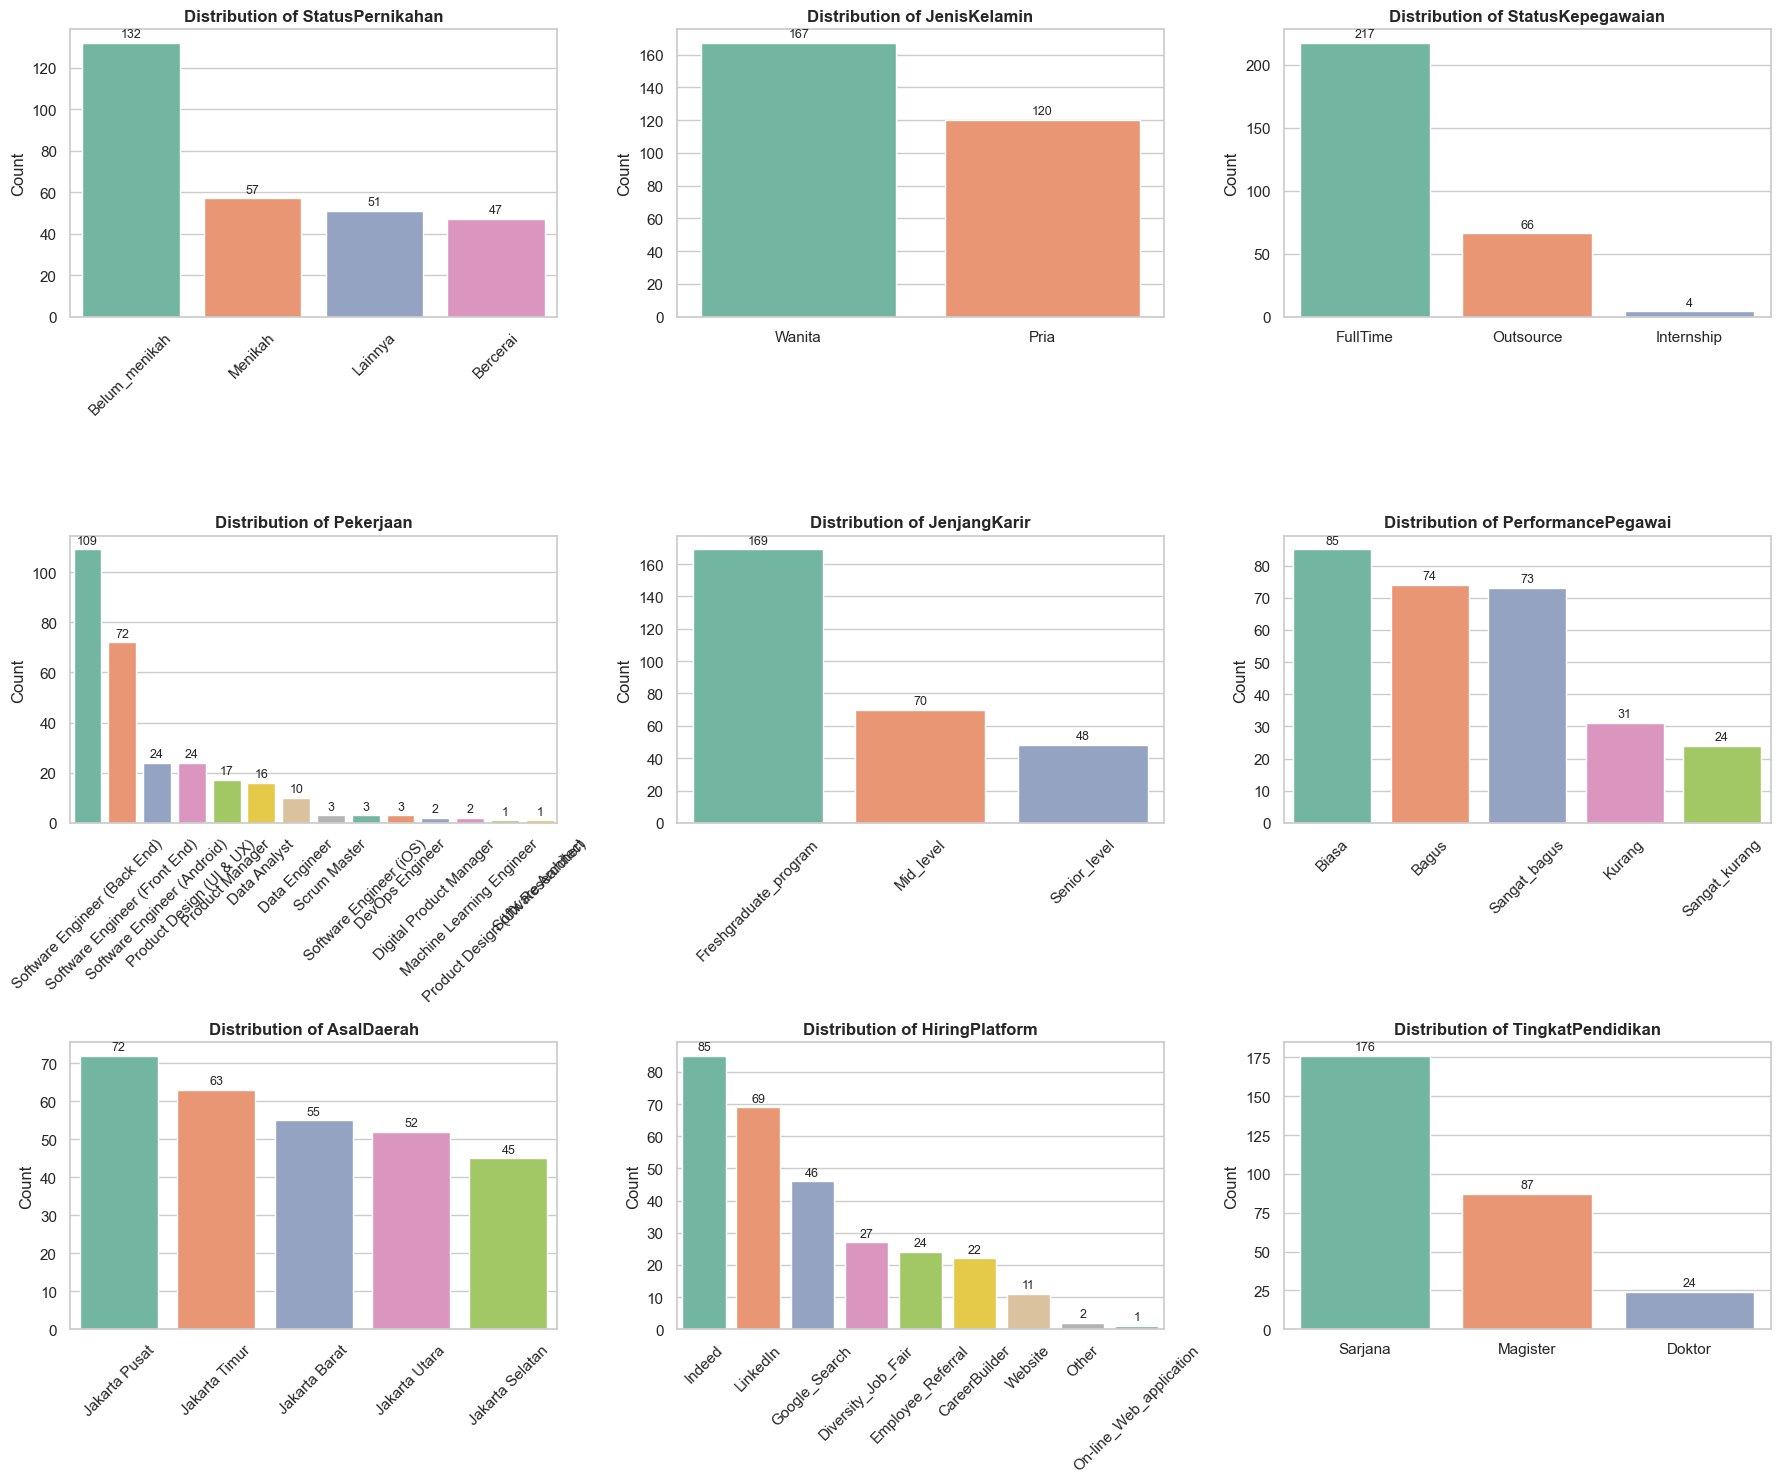

In [20]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all categorical (object, category, bool) columns
categorical_cols = df01.select_dtypes(
    include=["object", "category", "bool"]
).columns

# 2. Determine grid layout (e.g., 3 columns per row)
num_cols = len(categorical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array of axes into 1D for easy looping

# 4. Loop through columns and plot
for i, col in enumerate(categorical_cols):
    ax = axes[i]

    # Create countplot (ordered by highest frequency)
    order = df01[col].value_counts().index
    sns.countplot(x=col, data=df01, order=order, palette="Set2", ax=ax)

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")

    # Add count number labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        if not np.isnan(height) and height > 0:
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2.0, height),
                ha="center",
                va="bottom",
                fontsize=9,
                xytext=(0, 2),
                textcoords="offset points",
            )

    # Rotate labels if there are many unique values or long string names
    if df01[col].nunique() > 4 or df01[col].astype(str).str.len().max() > 10:
        ax.tick_params(axis="x", rotation=45)

# 5. Hide any extra unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

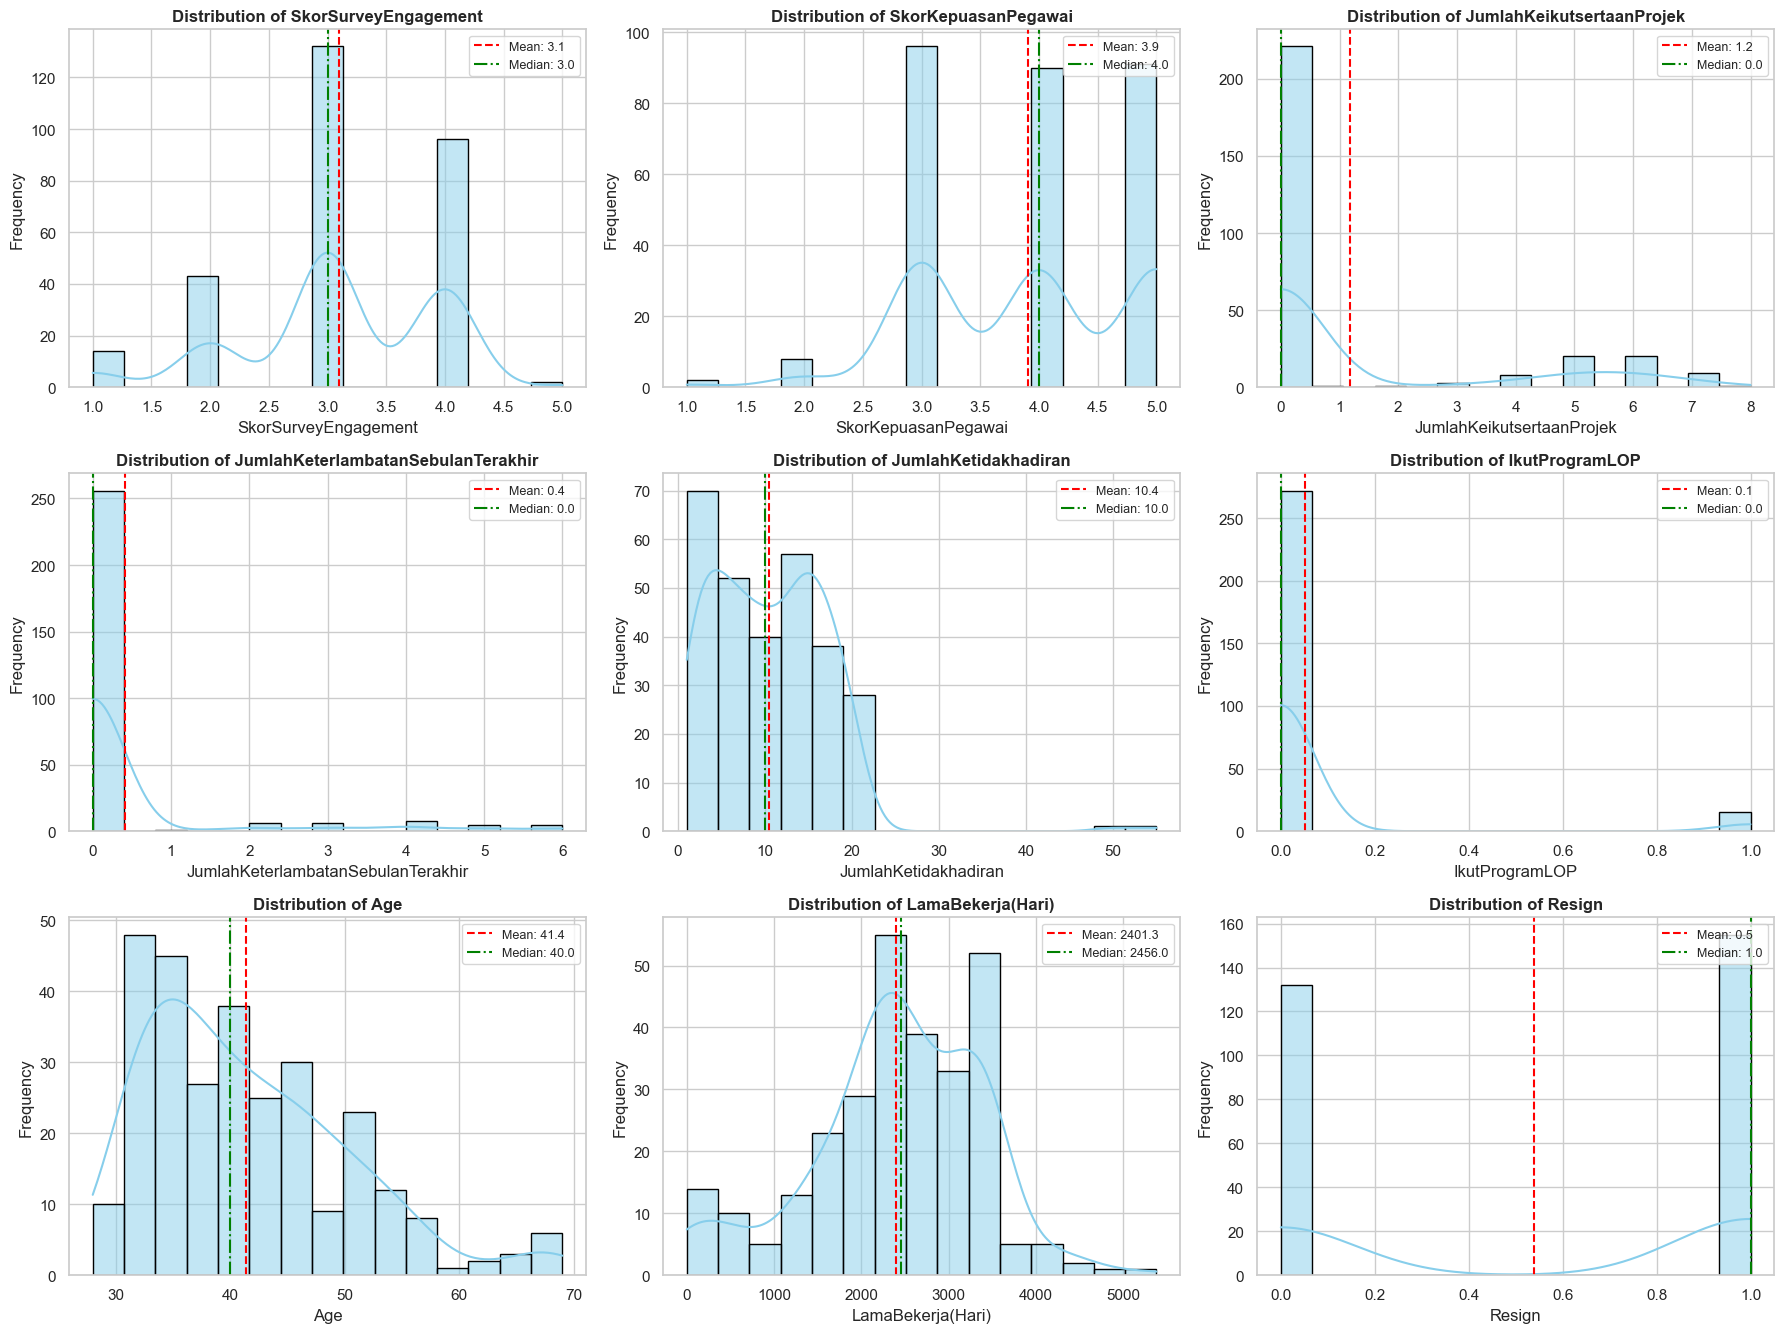

In [21]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Automatically identify all numerical (int, float) columns
numerical_cols = df01.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns

# 2. Determine grid layout (3 columns per row)
num_cols = len(numerical_cols)
cols_per_row = 3
rows = math.ceil(num_cols / cols_per_row)

# 3. Create subplots canvas
fig, axes = plt.subplots(
    rows, cols_per_row, figsize=(18, 4.5 * rows), squeeze=False
)
axes = axes.flatten()  # Flatten 2D array into 1D for easy looping

# 4. Loop through numerical columns and plot histograms
for i, col in enumerate(numerical_cols):
    ax = axes[i]

    # Create histogram with KDE overlay
    sns.histplot(
        data=df01,
        x=col,
        kde=True,
        color="skyblue",
        edgecolor="black",
        bins=15,
        ax=ax,
    )

    # Calculate mean and median for visual reference
    mean_val = df01[col].mean()
    median_val = df01[col].median()

    # Add vertical dashed lines for mean (red) and median (green)
    ax.axvline(
        mean_val,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Mean: {mean_val:.1f}",
    )
    ax.axvline(
        median_val,
        color="green",
        linestyle="-.",
        linewidth=1.5,
        label=f"Median: {median_val:.1f}",
    )

    # Styling
    ax.set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=9, loc="upper right")

# 5. Hide any unused subplot slots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()